# Обнаружение мошенничества в банковских транзакциях

Модель классификации для выявления мошеннических транзакций с использованием CatBoost.
Данные агрегированы на уровне клиентов для надежного предсказания мошенничества.
**Версия Pro: Подбор гиперпараметров с Optuna (100 итераций, оптимизация на F0.5)**

## Часть 1: Настройка окружения

Инициализация зависимостей, логирования и параметров визуализации.

In [1]:
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    average_precision_score
)
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# Настройка
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
logger.info("Окружение инициализировано")

/Users/berdov/project3/fraud_detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-11 11:16:10,821 - INFO - Окружение инициализировано


## Часть 2: Загрузка и исследование данных

Загрузка тренировочного и тестового наборов, анализ структуры и распределения мошенничества.

In [2]:
from pathlib import Path

DATA_DIR = Path("../data")

df_train = pd.read_csv(DATA_DIR / "train_clean.csv", index_col=False)
df_val = pd.read_csv(DATA_DIR / "val_clean.csv", index_col=False)
df_test = pd.read_csv(DATA_DIR / "test_clean.csv", index_col=False)

logger.info(f"Train: {df_train.shape[0]:,} строк x {df_train.shape[1]} колонок")
logger.info(f"Val:   {df_val.shape[0]:,} строк x {df_val.shape[1]} колонок")
logger.info(f"Test:  {df_test.shape[0]:,} строк x {df_test.shape[1]} колонок")

logger.info(f"Доля мошенничества train: {df_train['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества val:   {df_val['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества test:  {df_test['FraudResult'].mean():.2%}")

print("\nСводка по данным:")
print(f"  Источник:      {DATA_DIR}")
print(f"  Train строк:   {df_train.shape[0]:>8,}")
print(f"  Val строк:     {df_val.shape[0]:>8,}")
print(f"  Test строк:    {df_test.shape[0]:>8,}")
print(f"  Колонок:       {df_train.shape[1]:>8}")


2026-05-11 11:16:10,923 - INFO - Train: 57,364 строк x 24 колонок
2026-05-11 11:16:10,923 - INFO - Val:   19,162 строк x 24 колонок
2026-05-11 11:16:10,924 - INFO - Test:  19,136 строк x 24 колонок
2026-05-11 11:16:10,925 - INFO - Доля мошенничества train: 0.20%
2026-05-11 11:16:10,925 - INFO - Доля мошенничества val:   0.21%
2026-05-11 11:16:10,925 - INFO - Доля мошенничества test:  0.20%



Сводка по данным:
  Источник:      ../data
  Train строк:     57,364
  Val строк:       19,162
  Test строк:      19,136
  Колонок:             24


### Анализ распределения сущностей

In [3]:
# Данные уже разделены на train, val и test
logger.info("Используются заранее подготовленные train_clean.csv, val_clean.csv и test_clean.csv")

2026-05-11 11:16:10,930 - INFO - Используются заранее подготовленные train_clean.csv, val_clean.csv и test_clean.csv


## Часть 3: Обработка признаков

Использование признаков, заранее подготовленных и закодированных в data/cleanup.ipynb.

In [4]:
id_analysis = {
    'Всего строк': df_train.shape[0],
    'Уникальных CustomerId': df_train['CustomerId'].nunique(),
}

print("\nКардинальность сущностей в train:")
print("-" * 40)
for key, val in id_analysis.items():
    print(f"  {key:<25} {val:>10,}")


Кардинальность сущностей в train:
----------------------------------------
  Всего строк                   57,364
  Уникальных CustomerId          2,245


### Использование подготовленных признаков

In [5]:
# Все признаки уже подготовлены в data/cleanup.ipynb.
train_prep = df_train.copy()
val_prep = df_val.copy()
test_prep = df_test.copy()

logger.info(f"Train подготовлен: {train_prep.shape}")
logger.info(f"Val подготовлен:   {val_prep.shape}")
logger.info(f"Test подготовлен:  {test_prep.shape}")


2026-05-11 11:16:10,950 - INFO - Train подготовлен: (57364, 24)
2026-05-11 11:16:10,950 - INFO - Val подготовлен:   (19162, 24)
2026-05-11 11:16:10,950 - INFO - Test подготовлен:  (19136, 24)


### Выбор признаков

In [6]:
TARGET_COL = "FraudResult"
CLIENT_ID_COL = "CustomerId"

cat_features = [
    "ProviderId_id",
    "ProductId_id",
    "ProductCategory_id",
    "ChannelId_id",
    "PricingStrategy_id",
]

feature_cols = [
    col for col in train_prep.columns
    if col not in {TARGET_COL, CLIENT_ID_COL}
]

logger.info(f"Выбрано признаков: {len(feature_cols)}")
logger.info(f"Категориальные признаки CatBoost: {cat_features}")

print(f"\nПризнаки: {', '.join(sorted(feature_cols))}")
print(f"Категориальные признаки CatBoost: {cat_features}")


2026-05-11 11:16:10,955 - INFO - Выбрано признаков: 22
2026-05-11 11:16:10,956 - INFO - Категориальные признаки CatBoost: ['ProviderId_id', 'ProductId_id', 'ProductCategory_id', 'ChannelId_id', 'PricingStrategy_id']



Признаки: Amount, ChannelId_id, PricingStrategy_id, ProductCategory_id, ProductId_id, ProviderId_id, abs_amount, amount_sign, is_negative_amount, log_abs_amount, tx_day, tx_dayofweek, tx_dayofweek_cos, tx_dayofweek_sin, tx_elapsed_days, tx_elapsed_seconds, tx_hour, tx_hour_cos, tx_hour_sin, tx_is_weekend, tx_minute, tx_month
Категориальные признаки CatBoost: ['ProviderId_id', 'ProductId_id', 'ProductCategory_id', 'ChannelId_id', 'PricingStrategy_id']


### Подготовка матриц обучения

In [7]:
X_train = train_prep[feature_cols].copy()
y_train = train_prep[TARGET_COL].copy()

X_val = val_prep[feature_cols].copy()
y_val = val_prep[TARGET_COL].copy()

X_test = test_prep[feature_cols].copy()
y_test = test_prep[TARGET_COL].copy()

# Проверка баланса
fraud_ratio_train = y_train.mean()
fraud_ratio_val = y_val.mean()
fraud_ratio_test = y_test.mean()

logger.info(f"Train: {len(X_train):,} объектов, {fraud_ratio_train:.2%} мошенничества")
logger.info(f"Val: {len(X_val):,} объектов, {fraud_ratio_val:.2%} мошенничества")
logger.info(f"Test: {len(X_test):,} объектов, {fraud_ratio_test:.2%} мошенничества")

print(f"\nРазмеры матриц:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  y_val: {y_val.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

2026-05-11 11:16:10,969 - INFO - Train: 57,364 объектов, 0.20% мошенничества
2026-05-11 11:16:10,969 - INFO - Val: 19,162 объектов, 0.21% мошенничества
2026-05-11 11:16:10,969 - INFO - Test: 19,136 объектов, 0.20% мошенничества



Размеры матриц:
  X_train: (57364, 22)
  y_train: (57364,)
  X_val: (19162, 22)
  y_val: (19162,)
  X_test: (19136, 22)
  y_test: (19136,)


## Часть 4: Подбор гиперпараметров с Optuna

Оптимизация 100 итераций на F0.5 с использованием Optuna и CatBoost.

[I 2026-05-11 11:16:10,980] A new study created in memory with name: no-name-689b15b9-2795-4d48-a894-d94de1bab0d5
2026-05-11 11:16:10,981 - INFO - Starting Optuna optimization: 100 trials...
Best trial: 0. Best value: 0.697674:   1%|          | 1/100 [00:02<03:37,  2.20s/it]

[I 2026-05-11 11:16:13,230] Trial 0 finished with value: 0.6976744186046512 and parameters: {'depth': 6, 'learning_rate': 0.22648248189516842, 'l2_leaf_reg': 29.10635913133069, 'subsample': 0.7993292420985183, 'iterations': 700, 'random_strength': 0.20511104188433976, 'border_count': 45, 'bagging_temperature': 8.661761457749352, 'leaf_estimation_iterations': 7}. Best is trial 0 with value: 0.6976744186046512.


Best trial: 1. Best value: 0.847458:   2%|▏         | 2/100 [00:05<04:15,  2.61s/it]

[I 2026-05-11 11:16:16,127] Trial 1 finished with value: 0.847457627118644 and parameters: {'depth': 8, 'learning_rate': 0.001124579825911934, 'l2_leaf_reg': 87.06020878304857, 'subsample': 0.9162213204002109, 'iterations': 800, 'random_strength': 0.23102018878452935, 'border_count': 73, 'bagging_temperature': 3.0424224295953772, 'leaf_estimation_iterations': 6}. Best is trial 1 with value: 0.847457627118644.


Best trial: 2. Best value: 0.909091:   3%|▎         | 3/100 [00:06<03:14,  2.01s/it]

...

[I 2026-05-11 11:20:44,868] Trial 97 finished with value: 1.0 and parameters: {'depth': 4, 'learning_rate': 0.2422169745924809, 'l2_leaf_reg': 2.392839297602109, 'subsample': 0.6330216202202027, 'iterations': 1000, 'random_strength': 0.5571722282004274, 'border_count': 173, 'bagging_temperature': 7.886356397187871, 'leaf_estimation_iterations': 8}. Best is trial 22 with value: 1.0.


Best trial: 22. Best value: 1:  99%|█████████▉| 99/100 [04:36<00:02,  2.66s/it]

[I 2026-05-11 11:20:47,764] Trial 98 finished with value: 0.9803921568627451 and parameters: {'depth': 4, 'learning_rate': 0.21191818456595066, 'l2_leaf_reg': 2.9226165754976536, 'subsample': 0.6010502625791847, 'iterations': 900, 'random_strength': 0.34803744793862595, 'border_count': 177, 'bagging_temperature': 8.738762712704665, 'leaf_estimation_iterations': 7}. Best is trial 22 with value: 1.0.


Best trial: 22. Best value: 1: 100%|██████████| 100/100 [04:38<00:00,  2.79s/it]
2026-05-11 11:20:49,615 - INFO - Best trial: F0.5 = 1.000000
2026-05-11 11:20:49,615 - INFO - Best hyperparameters:
2026-05-11 11:20:49,615 - INFO -   depth: 5
2026-05-11 11:20:49,615 - INFO -   learning_rate: 0.07663001705074385
2026-05-11 11:20:49,615 - INFO -   l2_leaf_reg: 1.015372718369789
2026-05-11 11:20:49,615 - INFO -   subsample: 0.6625421697440483
2026-05-11 11:20:49,616 - INFO -   iterations: 1300
2026-05-11 11:20:49,616 - INFO -   random_strength: 0.15555988854707062
2026-05-11 11:20:49,616 - INFO -   border_count: 236
2026-05-11 11:20:49,616 - INFO -   bagging_temperature: 5.827132352425848
2026-05-11 11:20:49,616 - INFO -   leaf_estimation_iterations: 10


[I 2026-05-11 11:20:49,610] Trial 99 finished with value: 0.9574468085106383 and parameters: {'depth': 4, 'learning_rate': 0.2833708779839165, 'l2_leaf_reg': 2.026486699864947, 'subsample': 0.6618324857516739, 'iterations': 1100, 'random_strength': 0.39463776769513137, 'border_count': 152, 'bagging_temperature': 7.294321201972945, 'leaf_estimation_iterations': 8}. Best is trial 22 with value: 1.0.

                    OPTUNA OPTIMIZATION RESULTS (100 trials)                    

Best F0.5: 1.000000

Best Hyperparameters:
--------------------------------------------------------------------------------
  bagging_temperature                   5.827132
  border_count                               236
  depth                                        5
  iterations                                1300
  l2_leaf_reg                           1.015373
  leaf_estimation_iterations                  10
  learning_rate                         0.076630
  random_strength                       0.155560


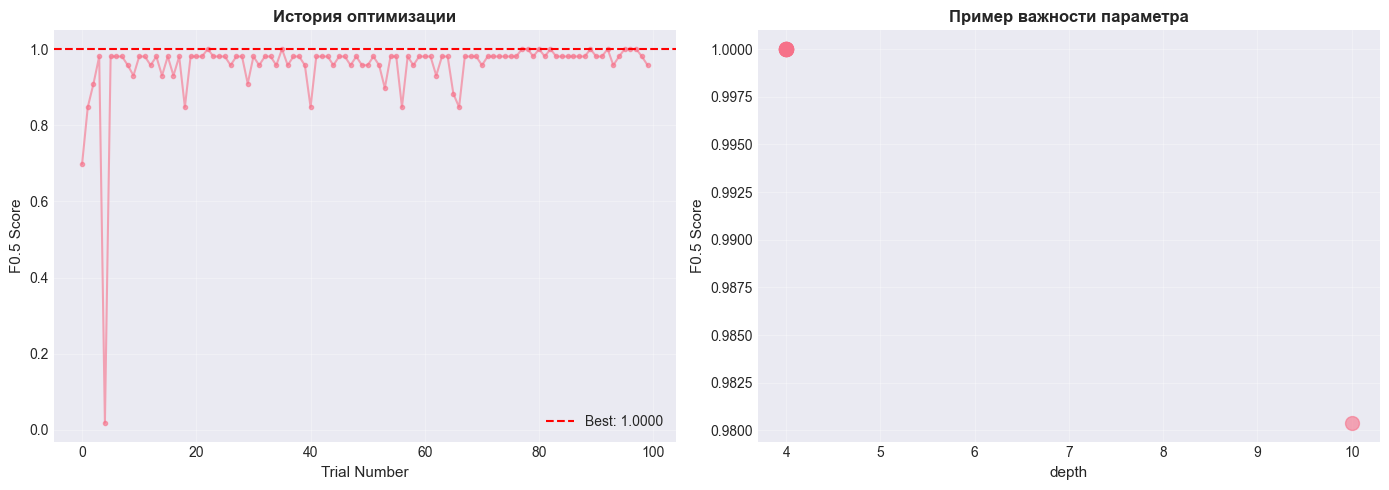


Оптимизация успешно завершена


In [8]:
def objective(trial):
    """
    Целевая функция Optuna для подбора гиперпараметров CatBoost.
    Оптимизирует F0.5 на validation.
    """

    depth = trial.suggest_int('depth', 4, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 0.3, log=True)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1, 100, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    iterations = trial.suggest_int('iterations', 500, 2000, step=100)
    random_strength = trial.suggest_float('random_strength', 0.1, 10.0, log=True)
    border_count = trial.suggest_int('border_count', 32, 255)
    bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 10.0)
    leaf_estimation_iterations = trial.suggest_int('leaf_estimation_iterations', 1, 10)

    model = CatBoostClassifier(
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        subsample=subsample,
        iterations=iterations,
        random_strength=random_strength,
        border_count=border_count,
        bagging_temperature=bagging_temperature,
        leaf_estimation_iterations=leaf_estimation_iterations,
        random_seed=42,
        verbose=0,
        early_stopping_rounds=50,
        eval_metric='PRAUC',
        use_best_model=True
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        cat_features=cat_features,
        plot=False
    )

    y_val_score = model.predict_proba(X_val)[:, 1]
    val_client_data = pd.DataFrame({
        CLIENT_ID_COL: val_prep[CLIENT_ID_COL].values,
        'y_true': y_val.values,
        'y_score': y_val_score
    })

    val_client_eval = val_client_data.groupby(CLIENT_ID_COL, as_index=False).agg({
        'y_true': 'max',
        'y_score': 'max'
    })

    y_val_client_true = val_client_eval['y_true'].values
    y_val_client_score = val_client_eval['y_score'].values

    thresholds = np.arange(0.0, 1.01, 0.01)
    f05_scores = []

    for thresh in thresholds:
        y_val_client_pred = (y_val_client_score >= thresh).astype(int)
        f05 = fbeta_score(y_val_client_true, y_val_client_pred, beta=0.5, zero_division=0)
        f05_scores.append(f05)

    best_f05 = max(f05_scores)
    trial.report(best_f05, step=0)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return best_f05


# Создаем study
sampler = TPESampler(seed=42, n_startup_trials=5)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner
)

# Запускаем оптимизацию на 100 trials
logger.info("Starting Optuna optimization: 100 trials...")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Берем лучший trial
best_trial = study.best_trial
logger.info(f"Best trial: F0.5 = {best_trial.value:.6f}")
logger.info(f"Best hyperparameters:")
for key, value in best_trial.params.items():
    logger.info(f"  {key}: {value}")

print("\n" + "="*80)
print(f"OPTUNA OPTIMIZATION RESULTS (100 trials)".center(80))
print("="*80)
print(f"\nBest F0.5: {best_trial.value:.6f}")
print(f"\nBest Hyperparameters:")
print("-"*80)
for key, value in sorted(best_trial.params.items()):
    if isinstance(value, float):
        print(f"  {key:<30} {value:>15.6f}")
    else:
        print(f"  {key:<30} {value:>15}")

# Визуализация истории оптимизации
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Значения trial по итерациям
trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_values, marker='o', markersize=3, alpha=0.6)
axes[0].axhline(best_trial.value, color='red', linestyle='--', label=f'Best: {best_trial.value:.4f}')
axes[0].set_xlabel('Trial Number', fontsize=11)
axes[0].set_ylabel('F0.5 Score', fontsize=11)
axes[0].set_title('История оптимизации', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# График срезов для топ-10 параметров
top_params = sorted(study.trials[-50:], key=lambda t: t.value if t.value else 0, reverse=True)[:10]
param_names = list(best_trial.params.keys())
param_values = {name: [] for name in param_names}
scores = []

for trial in top_params:
    if trial.value:
        for name in param_names:
            param_values[name].append(trial.params.get(name))
        scores.append(trial.value)

# График изменения главного параметра
if param_values[param_names[0]]:
    axes[1].scatter(param_values[param_names[0]], scores, s=100, alpha=0.6)
    axes[1].set_xlabel(param_names[0], fontsize=11)
    axes[1].set_ylabel('F0.5 Score', fontsize=11)
    axes[1].set_title(f'Пример важности параметра', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nОптимизация успешно завершена")

## Часть 5: Обучение финальной модели

Обучение модели с лучшими найденными гиперпараметрами на train.

In [9]:
logger.info(f"Обучение финальной модели на train: {X_train.shape}")

final_model = CatBoostClassifier(
    depth=int(best_trial.params['depth']),
    learning_rate=best_trial.params['learning_rate'],
    l2_leaf_reg=best_trial.params['l2_leaf_reg'],
    subsample=best_trial.params['subsample'],
    iterations=int(best_trial.params['iterations']),
    random_strength=best_trial.params['random_strength'],
    border_count=int(best_trial.params['border_count']),
    bagging_temperature=best_trial.params['bagging_temperature'],
    leaf_estimation_iterations=int(best_trial.params['leaf_estimation_iterations']),
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    eval_metric='PRAUC',
    use_best_model=True
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    cat_features=cat_features,
    plot=False
)

logger.info("Финальная модель обучена")


2026-05-11 11:20:49,784 - INFO - Обучение финальной модели на train: (57364, 22)


0:	learn: 0.7047582	test: 0.4092910	best: 0.4092910 (0)	total: 17.6ms	remaining: 22.9s
100:	learn: 0.9897336	test: 0.6838520	best: 0.6847104 (94)	total: 2.13s	remaining: 25.3s
200:	learn: 0.9964639	test: 0.6845054	best: 0.6884082 (197)	total: 4.28s	remaining: 23.4s


2026-05-11 11:20:55,492 - INFO - Финальная модель обучена


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6895205348
bestIteration = 213

Shrink model to first 214 iterations.


## Часть 6: Инференс модели

Генерация предсказаний для тестового набора на уровне транзакций и клиентов.

In [10]:
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Диагностическая информация
logger.info(f"Предсказания построены для {len(y_pred_proba):,} test-объектов")
logger.info(f"Статистика score - min: {y_pred_proba.min():.6f}, max: {y_pred_proba.max():.6f}, mean: {y_pred_proba.mean():.6f}")
logger.info(f"Score >= 0.5: {(y_pred_proba >= 0.5).sum()}")

y_pred = (y_pred_proba >= 0.5).astype(int)

2026-05-11 11:20:55,511 - INFO - Предсказания построены для 19,136 test-объектов
2026-05-11 11:20:55,512 - INFO - Статистика score - min: 0.000000, max: 0.999417, mean: 0.002310
2026-05-11 11:20:55,513 - INFO - Score >= 0.5: 44


### Агрегация на уровень клиентов

In [11]:
# Агрегация транзакционных предсказаний на уровень клиента
client_data = pd.DataFrame({
    CLIENT_ID_COL: test_prep[CLIENT_ID_COL].values,
    'y_true': y_test.values,
    'y_score': y_pred_proba
})

# Группируем по клиенту: берём максимальный score и наличие мошенничества
client_eval = client_data.groupby(CLIENT_ID_COL, as_index=False).agg({
    'y_true': 'max',
    'y_score': 'max'
})

client_eval.columns = [CLIENT_ID_COL, 'y_true_client', 'y_score_client']
client_eval['y_pred_client'] = (client_eval['y_score_client'] >= 0.5).astype(int)

logger.info(f"Агрегировано до {len(client_eval):,} уникальных клиентов")
logger.info(f"Истинных мошеннических клиентов: {(client_eval['y_true_client'] == 1).sum()}")
logger.info(f"Предсказано мошеннических клиентов: {(client_eval['y_pred_client'] == 1).sum()}")
logger.info(f"Статистика клиентских score - min: {client_eval['y_score_client'].min():.6f}, max: {client_eval['y_score_client'].max():.6f}, mean: {client_eval['y_score_client'].mean():.6f}")

2026-05-11 11:20:55,522 - INFO - Агрегировано до 749 уникальных клиентов
2026-05-11 11:20:55,523 - INFO - Истинных мошеннических клиентов: 11
2026-05-11 11:20:55,523 - INFO - Предсказано мошеннических клиентов: 13
2026-05-11 11:20:55,523 - INFO - Статистика клиентских score - min: 0.000000, max: 0.999417, mean: 0.016543


## Часть 7: Оценка модели

Расчет комплексных метрик, визуализация производительности, анализ по бакетам скора.

2026-05-11 11:20:55,607 - INFO - Оптимальный порог по validation: 0.04 (макс F0.5: 1.0000)



ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ CATBOOST PRO (OPTUNA + F0.5, КЛИЕНТСКИЙ УРОВЕНЬ)

СТАТИСТИКА НАБОРА ДАННЫХ:
--------------------------------------------------------------------------------
  Всего клиентов:                       749    (100.0%)
  Мошенники:                             11    (  1.5%)
  Честные:                              738    ( 98.5%)

РАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:
--------------------------------------------------------------------------------
  Предсказано как мошенник:             15    (  2.0%)
  Предсказано как честный:             734    ( 98.0%)
  Оптимальный порог:                 0.0400

МАТРИЦА ОШИБОК:
--------------------------------------------------------------------------------
  Истинные негативы (TN):               734
  Ложные позитивы (FP):                   4
  Ложные негативы (FN):                   0
  Истинные позитивы (TP):                11

МЕТРИКИ КАЧЕСТВА:
--------------------------------------------------------------------------------
  Accuracy / 

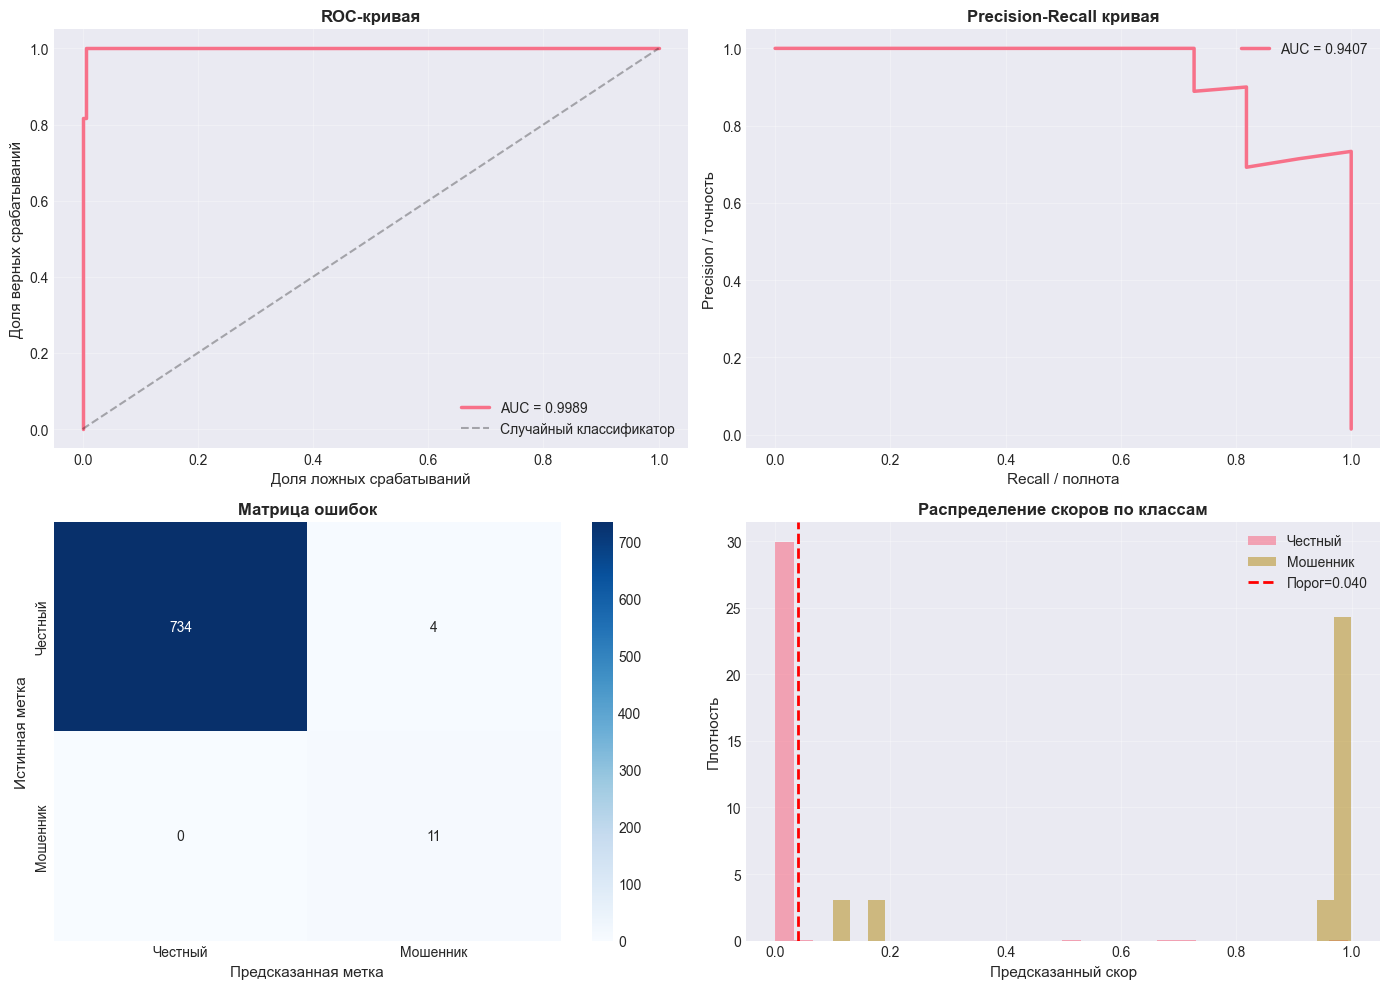

2026-05-11 11:20:55,821 - INFO - Оценка модели завершена успешно


In [12]:
y_true = client_eval['y_true_client'].values
y_score = client_eval['y_score_client'].values

# ===== Подбор порога на validation =====
val_pred_proba = final_model.predict_proba(X_val)[:, 1]

val_client_data = pd.DataFrame({
    CLIENT_ID_COL: val_prep[CLIENT_ID_COL].values,
    'y_true': y_val.values,
    'y_score': val_pred_proba
})

val_client_eval = val_client_data.groupby(CLIENT_ID_COL, as_index=False).agg({
    'y_true': 'max',
    'y_score': 'max'
})

val_client_eval.columns = [CLIENT_ID_COL, 'y_true_client', 'y_score_client']

y_val_client_true = val_client_eval['y_true_client'].values
y_val_client_score = val_client_eval['y_score_client'].values

thresholds = np.arange(0.0, 1.01, 0.01)
f05_scores = []

for thresh in thresholds:
    y_val_client_pred = (y_val_client_score >= thresh).astype(int)
    f05 = fbeta_score(y_val_client_true, y_val_client_pred, beta=0.5, zero_division=0)
    f05_scores.append(f05)

optimal_thresh = thresholds[np.argmax(f05_scores)]

logger.info(f"Оптимальный порог по validation: {optimal_thresh:.2f} (макс F0.5: {max(f05_scores):.4f})")

y_true = client_eval['y_true_client'].values
y_score = client_eval['y_score_client'].values
y_pred = (y_score >= optimal_thresh).astype(int)

# Расчет метрик
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics = {
    'ROC-AUC': roc_auc_score(y_true, y_score),
    'PR-AUC': average_precision_score(y_true, y_score),
    'Accuracy / доля верных ответов': accuracy_score(y_true, y_pred),
    'Precision / точность': precision_score(y_true, y_pred, zero_division=0),
    'Recall / полнота': recall_score(y_true, y_pred, zero_division=0),
    'F1': f1_score(y_true, y_pred, zero_division=0),
    'F0.5': fbeta_score(y_true, y_pred, beta=0.5, zero_division=0),
    'Полнота по честным клиентам': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
    'FNR': fn / (fn + tp) if (fn + tp) > 0 else 0.0,
    'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0.0,
}

# Печать форматированного отчета
print("\n" + "="*80)
print("ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ CATBOOST PRO (OPTUNA + F0.5, КЛИЕНТСКИЙ УРОВЕНЬ)")
print("="*80)

print("\nСТАТИСТИКА НАБОРА ДАННЫХ:")
print("-"*80)
n_total = len(client_eval)
n_fraud = (y_true == 1).sum()
n_nonfraud = (y_true == 0).sum()
print(f"  Всего клиентов:                {n_total:>10,}    ({100.0:>5.1f}%)")
print(f"  Мошенники:                     {n_fraud:>10,}    ({100*n_fraud/n_total:>5.1f}%)")
print(f"  Честные:                       {n_nonfraud:>10,}    ({100*n_nonfraud/n_total:>5.1f}%)")

print("\nРАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:")
print("-"*80)
n_pred_fraud = (y_pred == 1).sum()
n_pred_legit = (y_pred == 0).sum()
print(f"  Предсказано как мошенник:     {n_pred_fraud:>10,}    ({100*n_pred_fraud/n_total:>5.1f}%)")
print(f"  Предсказано как честный:      {n_pred_legit:>10,}    ({100*n_pred_legit/n_total:>5.1f}%)")
print(f"  Оптимальный порог:             {optimal_thresh:>10.4f}")

print("\nМАТРИЦА ОШИБОК:")
print("-"*80)
print(f"  Истинные негативы (TN):        {tn:>10,}")
print(f"  Ложные позитивы (FP):          {fp:>10,}")
print(f"  Ложные негативы (FN):          {fn:>10,}")
print(f"  Истинные позитивы (TP):        {tp:>10,}")

print("\nМЕТРИКИ КАЧЕСТВА:")
print("-"*80)
for metric_name, metric_value in sorted(metrics.items()):
    print(f"  {metric_name:<25} {metric_value:>10.4f}")

print("\nДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ:")
print("-"*80)
print(classification_report(y_true, y_pred, target_names=['Честный', 'Мошенник'], 
                          digits=4, zero_division=0))

# Метрики по бакетам score
print("ПАРИТЕТ ПО БАКЕТАМ СКОРА (интервалы 0.1):")
print("-"*80)
buckets = pd.cut(y_score, bins=10, labels=[f"{i*0.1:.1f}-{(i+1)*0.1:.1f}" for i in range(10)])
parity_df = pd.DataFrame({
    'bucket': buckets,
    'y_true': y_true,
    'y_score': y_score
})

parity_stats = parity_df.groupby('bucket', observed=True).agg({
    'y_true': ['count', 'sum', 'mean'],
    'y_score': ['min', 'max', 'mean']
}).round(4)

parity_stats.columns = ['count', 'fraud_count', 'fraud_rate', 'score_min', 'score_max', 'score_mean']
print(parity_stats.to_string())

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC-кривая
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
axes[0, 0].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {metrics["ROC-AUC"]:.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Случайный классификатор')
axes[0, 0].set_xlabel('Доля ложных срабатываний', fontsize=11)
axes[0, 0].set_ylabel('Доля верных срабатываний', fontsize=11)
axes[0, 0].set_title('ROC-кривая', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# PR-кривая
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
axes[0, 1].plot(recall_vals, precision_vals, linewidth=2.5, label=f'AUC = {metrics["PR-AUC"]:.4f}')
axes[0, 1].set_xlabel('Recall / полнота', fontsize=11)
axes[0, 1].set_ylabel('Precision / точность', fontsize=11)
axes[0, 1].set_title('Precision-Recall кривая', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], 
           xticklabels=['Честный', 'Мошенник'],
           yticklabels=['Честный', 'Мошенник'])
axes[1, 0].set_ylabel('Истинная метка', fontsize=11)
axes[1, 0].set_xlabel('Предсказанная метка', fontsize=11)
axes[1, 0].set_title('Матрица ошибок', fontsize=12, fontweight='bold')

# Распределение score
axes[1, 1].hist(y_score[y_true == 0], bins=30, alpha=0.6, label='Честный', density=True)
axes[1, 1].hist(y_score[y_true == 1], bins=30, alpha=0.6, label='Мошенник', density=True)
axes[1, 1].axvline(optimal_thresh, color='red', linestyle='--', linewidth=2, label=f'Порог={optimal_thresh:.3f}')
axes[1, 1].set_xlabel('Предсказанный скор', fontsize=11)
axes[1, 1].set_ylabel('Плотность', fontsize=11)
axes[1, 1].set_title('Распределение скоров по классам', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("="*80)
logger.info("Оценка модели завершена успешно")